### Your First Unsupervised Learning Model: K-Means Clustering

First, we will import necessary dependencies. 

In [79]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

We will now load the Mall Customers dataset from Kaggle. This dataset contains demographic and spending information about customers. We’ll focus on Annual Income and Spending Score for clustering.

In [80]:
# Load data
df = pd.read_csv("dataset/Mall_Customers.csv")
# Columns CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Before clustering, let’s take a quick look at the relationship between Annual Income and Spending Score. Plotting these two features gives us an intuition about whether natural groupings exist.

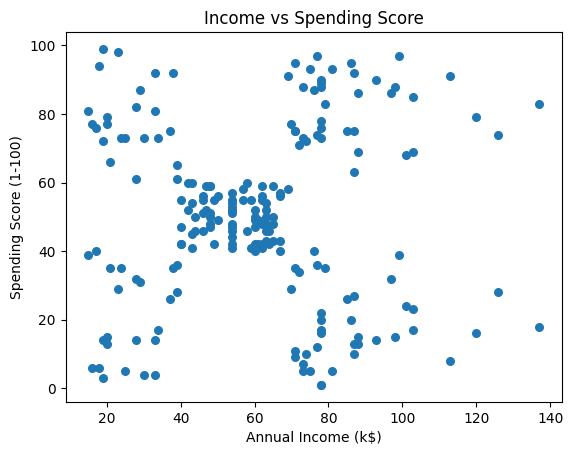

In [81]:
df[["Annual Income (k$)", "Spending Score (1-100)"]].plot(
    kind="scatter", x="Annual Income (k$)", y="Spending Score (1-100)", s=30
)
plt.title("Income vs Spending Score")
plt.show()

Clustering works best when features are on a similar scale. Here we:

1. Select the two columns: Annual Income and Spending Score

2. Standardize them so both have mean 0 and variance 1.

In [82]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K-Means requires us to pick the number of clusters k. To help decide, we:

1. Use the Elbow Method, which looks at inertia (how tightly grouped clusters are).

2. Use the Silhouette Score, which measures how well-separated clusters are.

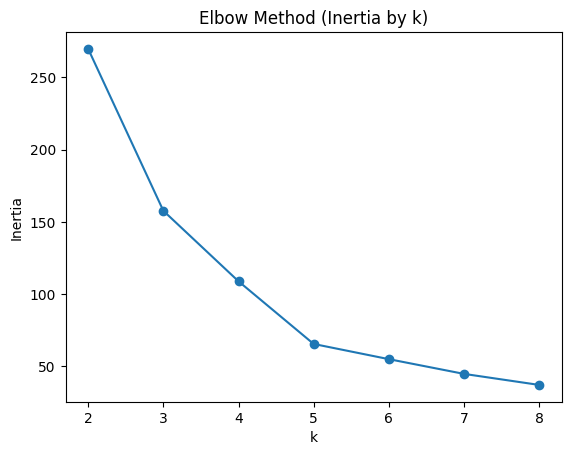

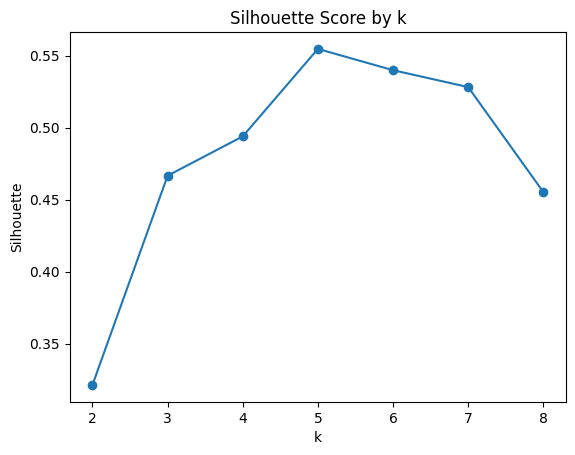

The best_k according to intertia and silhouette method is: 5


In [ ]:
inertias = []
sils = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

# Plot elbow
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method (Inertia by k)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.xticks(list(ks))
plt.show()

# Plot silhouette scores
plt.plot(list(ks), sils, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.xticks(list(ks))
plt.show()

best_k = int(ks[np.argmax(sils)])
print("The best_k according to intertia and silhouette methods is:",best_k)

In [89]:
k = best_k  # or set manually, e.g., k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df_clusters = X.copy()
df_clusters["Cluster"] = labels
df_clusters.head()


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


Using the best k from the silhouette score, we fit K-Means on the dataset. Then we plot the clusters, along with their centroids (the black stars).

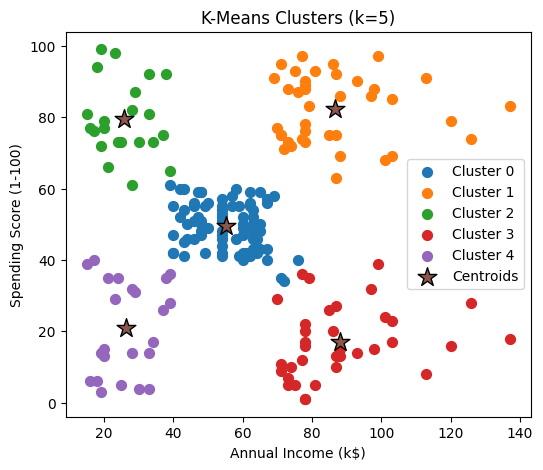

In [90]:
# Plot points
plt.figure(figsize=(6,5))
for c in sorted(np.unique(labels)):
    ix = labels == c
    plt.scatter(X.iloc[ix, 0], X.iloc[ix, 1], s=50, label=f"Cluster {c}")

# Centroids need to be inverse-transformed back to original scale for plotting
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
plt.scatter(centroids[:,0], centroids[:,1], s=200, marker="*", edgecolor="k", label="Centroids")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"K-Means Clusters (k={k})")
plt.legend()
plt.show()


Finally, we can summarize each cluster with basic statistics:

1. Number of customers

2. Average income

3. Average spending score

This helps interpret the business meaning of each cluster.

In [91]:
profiles = df_clusters.groupby("Cluster").agg(
    count=("Cluster","size"),
    avg_income=("Annual Income (k$)","mean"),
    avg_score=("Spending Score (1-100)","mean"),
).sort_index()

profiles


,count,avg_income,avg_score
Cluster,,,
0,81,55.296296,49.518519
1,39,86.538462,82.128205
2,22,25.727273,79.363636
3,35,88.200000,17.114286
4,23,26.304348,20.913043


### K-Means in Action

To make the animation smoother, we’ll initialize centroids using the k-means++ method. This spreads initial centroids apart, reducing bad starting positions.

We implement K-Means manually to capture each iteration. After every update step (assigning points to clusters and recomputing centroids), we save a PNG snapshot for the animation.

Finally, we stitch the snapshots into a GIF. Setting loop=0 ensures the animation plays continuously. We then display it inline in the notebook.

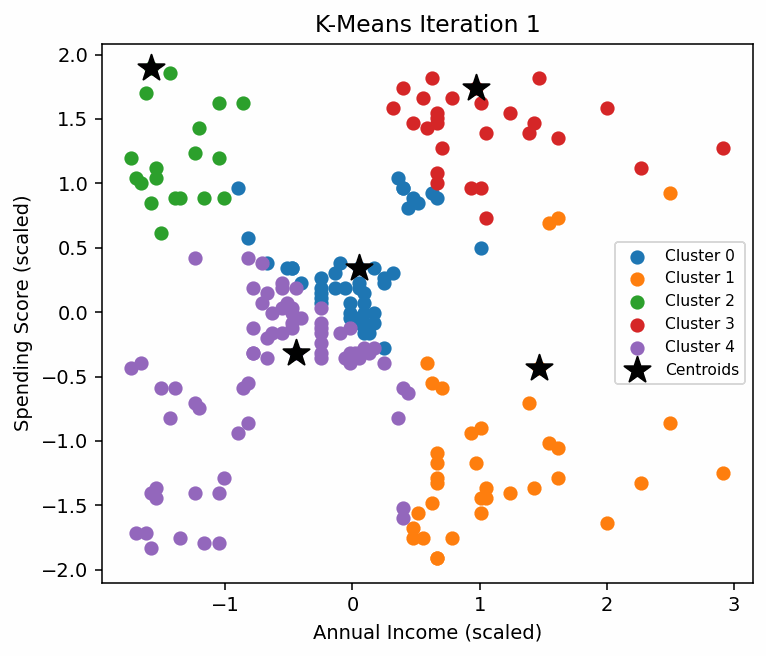

In [92]:
def kmeans_pp_init(X, k, rng):
    n = X.shape[0]
    centroids = np.empty((k, X.shape[1]))
    # pick first centroid
    centroids[0] = X[rng.randint(n)]
    # pick remaining
    for i in range(1, k):
        d2 = np.min(np.linalg.norm(X[:, None] - centroids[:i], axis=2)**2, axis=1)
        probs = d2 / d2.sum()
        idx = rng.choice(n, p=probs)
        centroids[i] = X[idx]
    return centroids

os.makedirs("kmeans_steps", exist_ok=True)

def run_kmeans_snapshots(X, k=5, max_iters=12, seed=42, folder="kmeans_steps"):
    rng = np.random.RandomState(seed)
    centroids = kmeans_pp_init(X, k, rng)

    snapshots = []
    for i in range(1, max_iters+1):
        # Assign
        dists = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        labels = np.argmin(dists, axis=1)

        # Plot snapshot (scaled units for clarity)
        plt.figure(figsize=(6,5))
        for c in range(k):
            plt.scatter(X[labels==c, 0], X[labels==c, 1], s=40, label=f"Cluster {c}")
        plt.scatter(centroids[:,0], centroids[:,1], c="black", marker="*", s=200, label="Centroids")
        plt.title(f"K-Means Iteration {i}")
        plt.xlabel("Annual Income (scaled)")
        plt.ylabel("Spending Score (scaled)")
        plt.legend(loc="best", fontsize=8, frameon=True)

        fname = f"{folder}/iter_{i:02d}.png"
        plt.savefig(fname, dpi=140, bbox_inches="tight")
        plt.close()
        snapshots.append(fname)

        # Update
        new_centroids = np.vstack([
            X[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
            for c in range(k)
        ])

        if np.allclose(centroids, new_centroids, atol=1e-4):
            # one extra final frame to hold on convergence
            break

        centroids = new_centroids

    return snapshots

snapshots = run_kmeans_snapshots(X_scaled, k=k, max_iters=15, seed=42)
len(snapshots), snapshots[:3]

from IPython.display import Image

gif_path = "kmeans_animation.gif"
with imageio.get_writer(gif_path, mode="I", duration=2000, loop=0) as writer:  # loop=0 = infinite loop
    for filename in snapshots:
        writer.append_data(imageio.v2.imread(filename))

# Show inline in notebook
Image(filename=gif_path)


